# 4.8 Visualization of functional enrichment results (3)

Author: Xuezhu Sunny Wang

## Dataset 📊

- Gene lists of gene expression programs of the monocyte and dendritic cells

## Steps overview 📒
- Run GO BP enrichment for gene lists
- Plot the results


In [1]:
marker_table <- read.csv("./markers_out_mono/top50_markers_genename_table_wide.csv")
marker_table 

ramono,CD14.Mono.set2High,cDC2,pDC,CD14.Mono.set1High,CD16.Mono,pre.mDC,pre.pDC,Macrophage,cDC1,ASDC
<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,CXCL1,ENHO,COL26A1,DEFA3,LYPD2,HIST1H1B,IGLL1,HS3ST2,ERICH5,STMN2
2,CXCR1,CD1C,KRT5,CES1,CDKN1C,SPC25,SPINK2,CD5L,PPY,ATP1A2
3,ALPL,FCER1A,LRRC26,ARHGEF10L,AC104809.2,FAM111B,HIST1H3C,VCAM1,XCR1,ADAM33
4,CXCL8,PKIB,AC097375.1,STAB1,CKB,HIST1H1A,NGFR,CCL18,LINC02206,SIGLEC6
5,CST7,FBLN2,ASIP,NRG1,VMO1,CTSV,SNHG31,TMEM26,CADM1,VASN
6,PROK2,CD1E,LINC00996,PLCB1,NEURL1,PIMREG,HIST1H1B,IGSF21,CLNK,PPP1R14A
7,MME,GRIP1,PACSIN1,FGD6,HES4,E2F8,BAALC,FABP3,ZNF462,GPR146
8,CXCR2,NDRG2,LINC01478,NFIA,MTSS1,CENPM,HIST1H3B,APOE,TMEM132E,HAMP
9,G0S2,DEPTOR,NLRP7,CAMK2D,RHOC,HMMR,DNTT,TIMD4,ENPP1,AL592430.1


In [2]:
marker_table$ramono<-NULL

In [3]:
library(clusterProfiler)
library(org.Hs.eg.db)
library(enrichplot)
library(dplyr)

# Store all enrichment results
all_marker_enrichment <- list()

# Loop through each gene signature (column)
for (marker_name in colnames(marker_table)) {
  cat("Processing marker set:", marker_name, "\n")
  
  # Get the gene list from the column, remove NA
  geneList <- na.omit(marker_table[[marker_name]])
  
  # Skip empty sets
  if (length(geneList) < 3) {
    cat("Too few genes for enrichment in", marker_name, "\n")
    next
  }

  # Convert to Entrez ID
  gene.df <- bitr(geneList, fromType = "SYMBOL",
                  toType = "ENTREZID",
                  OrgDb = org.Hs.eg.db)

  if (nrow(gene.df) < 3) {
    cat("No valid Entrez IDs found for", marker_name, "\n")
    next
  }

  # Run enrichment
  ego <- enrichGO(gene = gene.df$ENTREZID,
                  OrgDb = org.Hs.eg.db,
                  keyType = "ENTREZID",
                  ont = "BP",
                  pvalueCutoff = 0.05,
                  qvalueCutoff = 0.2,
                  pAdjustMethod = "BH",
                  readable = TRUE)

  # Store results
  if (!is.null(ego) && nrow(as.data.frame(ego)) > 0) {
    ego_df <- as.data.frame(ego)
    ego_df$marker <- marker_name
    all_marker_enrichment[[marker_name]] <- ego_df
  } else {
    cat("No significant enrichment for", marker_name, "\n")
  }
}

# Combine all results into one table
combined_marker_enrichment <- bind_rows(all_marker_enrichment)

# Save to file
write.csv(combined_marker_enrichment, "GO_BP_enrichment_marker_sets-mono.csv", row.names = FALSE)

# Preview
head(combined_marker_enrichment)




Registered S3 methods overwritten by 'treeio':
  method              from    
  MRCA.phylo          tidytree
  MRCA.treedata       tidytree
  Nnode.treedata      tidytree
  Ntip.treedata       tidytree
  ancestor.phylo      tidytree
  ancestor.treedata   tidytree
  child.phylo         tidytree
  child.treedata      tidytree
  full_join.phylo     tidytree
  full_join.treedata  tidytree
  groupClade.phylo    tidytree
  groupClade.treedata tidytree
  groupOTU.phylo      tidytree
  groupOTU.treedata   tidytree
  inner_join.phylo    tidytree
  inner_join.treedata tidytree
  is.rooted.treedata  tidytree
  nodeid.phylo        tidytree
  nodeid.treedata     tidytree
  nodelab.phylo       tidytree
  nodelab.treedata    tidytree
  offspring.phylo     tidytree
  offspring.treedata  tidytree
  parent.phylo        tidytree
  parent.treedata     tidytree
  root.treedata       tidytree
  rootnode.phylo      tidytree
  sibling.phylo       tidytree

clusterProfiler v4.10.1  For help: https://yulab-sm

Processing marker set: CD14.Mono.set2High 


'select()' returned 1:1 mapping between keys and columns

Warning message in bitr(geneList, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Hs.eg.db):
“8% of input gene IDs are fail to map...”


Processing marker set: cDC2 


'select()' returned 1:1 mapping between keys and columns

Warning message in bitr(geneList, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Hs.eg.db):
“2% of input gene IDs are fail to map...”


...

Processing marker set: cDC1 


'select()' returned 1:1 mapping between keys and columns

Warning message in bitr(geneList, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Hs.eg.db):
“4% of input gene IDs are fail to map...”


Processing marker set: ASDC 


'select()' returned 1:1 mapping between keys and columns

Warning message in bitr(geneList, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Hs.eg.db):
“10% of input gene IDs are fail to map...”


,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count,marker
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>
GO:0030593,GO:0030593,neutrophil chemotaxis,6/43,107/18870,1.483525e-07,0.0001495393,0.0001146218,CXCL1/CXCR1/CXCL8/CXCR2/TNFAIP6/CCL4,6,CD14.Mono.set2High
GO:1990266,GO:1990266,neutrophil migration,6/43,129/18870,4.499411e-07,0.0001582286,0.0001212821,CXCL1/CXCR1/CXCL8/CXCR2/TNFAIP6/CCL4,6,CD14.Mono.set2High
GO:0071621,GO:0071621,granulocyte chemotaxis,6/43,130/18870,4.709184e-07,0.0001582286,0.0001212821,CXCL1/CXCR1/CXCL8/CXCR2/TNFAIP6/CCL4,6,CD14.Mono.set2High
GO:0006935...4,GO:0006935,chemotaxis,9/43,468/18870,8.764303e-07,0.0001807962,0.0001385802,CXCL1/CXCR1/CXCL8/PROK2/CXCR2/CMTM2/TNFAIP6/FFAR2/CCL4,9,CD14.Mono.set2High
GO:0042330...5,GO:0042330,taxis,9/43,470/18870,9.080275e-07,0.0001807962,0.0001385802,CXCL1/CXCR1/CXCL8/PROK2/CXCR2/CMTM2/TNFAIP6/FFAR2/CCL4,9,CD14.Mono.set2High
GO:0030595...6,GO:0030595,leukocyte chemotaxis,7/43,240/18870,1.076168e-06,0.0001807962,0.0001385802,CXCL1/CXCR1/CXCL8/CXCR2/TNFAIP6/FFAR2/CCL4,7,CD14.Mono.set2High


In [4]:
# Load packages
library(ggplot2)
library(readr)
library(dplyr)

df<-read.csv('GO_BP_enrichment_marker_sets-mono-selected.csv')
df$Descrtiption<-paste(df$ID,df$Description,sep=':')
df

ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count,marker,Descrtiption
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>,<chr>
GO:0043277,apoptotic cell clearance,4/43,48/18870,4.227656e-06,6.117418e-03,4.761675e-03,CCR2/CD36/MARCO/LRP1,4,CD14.Mono.set1High,GO:0043277:apoptotic cell clearance
GO:0097242,amyloid-beta clearance,3/43,39/18870,9.512654e-05,1.966401e-02,1.530607e-02,CD36/MARCO/LRP1,3,CD14.Mono.set1High,GO:0097242:amyloid-beta clearance
GO:0035696,monocyte extravasation,2/43,10/18870,2.256190e-04,3.627448e-02,2.823533e-02,PLCB1/CCR2,2,CD14.Mono.set1High,GO:0035696:monocyte extravasation
GO:0006898,receptor-mediated endocytosis,5/43,258/18870,2.893990e-04,3.806917e-02,2.963228e-02,STAB1/CD36/MARCO/ASGR1/LRP1,5,CD14.Mono.set1High,GO:0006898:receptor-mediated endocytosis
GO:0030593,neutrophil chemotaxis,6/43,107/18870,1.483525e-07,1.495390e-04,1.146220e-04,CXCL1/CXCR1/CXCL8/CXCR2/TNFAIP6/CCL4,6,CD14.Mono.set2High,GO:0030593:neutrophil chemotaxis
GO:0006925,inflammatory cell apoptotic process,2/43,24/18870,1.356049e-03,3.804564e-02,2.916197e-02,CXCR2/HCAR2,2,CD14.Mono.set2High,GO:0006925:inflammatory cell apoptotic process
GO:0000272,polysaccharide catabolic process,2/43,21/18870,1.036261e-03,3.165306e-02,2.426206e-02,PPP1R3B/MGAM,2,CD14.Mono.set2High,GO:0000272:polysaccharide catabolic process
GO:0019884,antigen processing and presentation of exogenous antigen,7/47,49/18870,2.959446e-11,2.296530e-08,1.822396e-08,CD1C/CD1E/HLA-DQA1/HLA-DQB2/HLA-DQA2/HLA-DOA/HLA-DPB1,7,cDC2,GO:0019884:antigen processing and presentation of exogenous antigen
GO:0002399,MHC class II protein complex assembly,5/47,16/18870,3.294364e-10,8.521422e-08,6.762116e-08,HLA-DQA1/HLA-DQB2/HLA-DQA2/HLA-DOA/HLA-DPB1,5,cDC2,GO:0002399:MHC class II protein complex assembly


In [5]:
table(df$marker)


CD14.Mono.set1High CD14.Mono.set2High               cDC2         Macrophage 
                 4                  6                  2                  5 

In [6]:
# ==== Packages ====
suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(stringr)
  library(ggplot2)
  library(viridis)
})

# ==== Helper: multi-sample GO bubble plot ====
bubble_go_multi <- function(
  df,
  sample_col   = "marker",
  term_col     = "Description",
  padj_col     = "p.adjust",
  count_col    = "Count",
  ratio_col    = "GeneRatio",   # if missing, size will fall back to Count
  top_n        = 12,            # keep N best terms per sample
  min_count    = 1,             # drop tiny terms
  wrap_width   = 40,            # wrap long GO term labels
  sample_order = NULL,          # set custom order of samples on x
  size_by      = c("GeneRatio","Count")  # which metric to use for point size
){
  size_by <- match.arg(size_by)
  stopifnot(all(c(sample_col, term_col, padj_col, count_col) %in% names(df)))

  df1 <- df %>%
    # standardize column names
    rename(
      sample = !!sym(sample_col),
      term   = !!sym(term_col),
      padj   = !!sym(padj_col),
      count  = !!sym(count_col)
    ) %>%
    mutate(term = str_trim(term)) %>%
    filter(!is.na(padj), !is.na(term), count >= min_count)

  # add GeneRatio if missing
  if (!ratio_col %in% names(df1) || all(is.na(df1[[ratio_col]]))) {
    df1 <- df1 %>% mutate(GeneRatio = count)
    message("`", ratio_col, "` not found or all NA; using Count for point sizes.")
  } else {
    df1 <- df1 %>% rename(GeneRatio = !!sym(ratio_col))
  }

  # keep best (lowest FDR) per (sample, term), then top N per sample
  df_top <- df1 %>%
    group_by(sample, term) %>%
    slice_min(padj, n = 1, with_ties = FALSE) %>%
    ungroup() %>%
    group_by(sample) %>%
    slice_min(padj, n = top_n, with_ties = TRUE) %>%
    ungroup()

  # order terms by global best FDR
  term_order <- df_top %>%
    group_by(term) %>%
    summarise(best_padj = min(padj, na.rm = TRUE), .groups = "drop") %>%
    arrange(best_padj) %>%
    pull(term)

  # order samples
  if (is.null(sample_order)) {
    sample_order <- df_top %>%
      group_by(sample) %>%
      summarise(median_p = median(padj, na.rm = TRUE), .groups = "drop") %>%
      arrange(median_p) %>%
      pull(sample)
  }

  # prep factors and choose size_var
  df_top <- df_top %>%
    mutate(
      sample = factor(sample, levels = sample_order),
      term_wrapped = factor(str_wrap(term, width = wrap_width),
                            levels = str_wrap(term_order, width = wrap_width)),
      size_var = if (size_by == "GeneRatio") GeneRatio else count
    )

  size_title <- if (size_by == "GeneRatio") "GeneRatio" else "Gene Count"

  # ---- PLOT ----
  p <- ggplot(df_top, aes(x = sample, y = term_wrapped)) +
  geom_point(aes(size = count, color = padj), alpha = 0.9) +
  scale_color_gradient(high = "#d9ecd3",low = "#2c3991", name = "FDR") +
  scale_size(range = c(2.5, 10), name = "Gene Count") +
  labs(x = "Group", y = NULL, title = "GO Enrichment Across Groups") +
  theme_bw() +
  theme(
    axis.text.y = element_text(size = 9),
    axis.text.x = element_text(size = 10, angle = 45, hjust = 1),
    plot.margin = margin(t = 5, r = 10, b = 5, l = 10)
  )
  return(p)
}



In [7]:
library(dplyr)

df <- df %>%
  mutate(
    GeneRatio = if (is.character(GeneRatio)) {
      # split at "/" and evaluate numerator/denominator
      sapply(strsplit(GeneRatio, "/"), function(x) as.numeric(x[1]) / as.numeric(x[2]))
    } else {
      GeneRatio
    }
  )


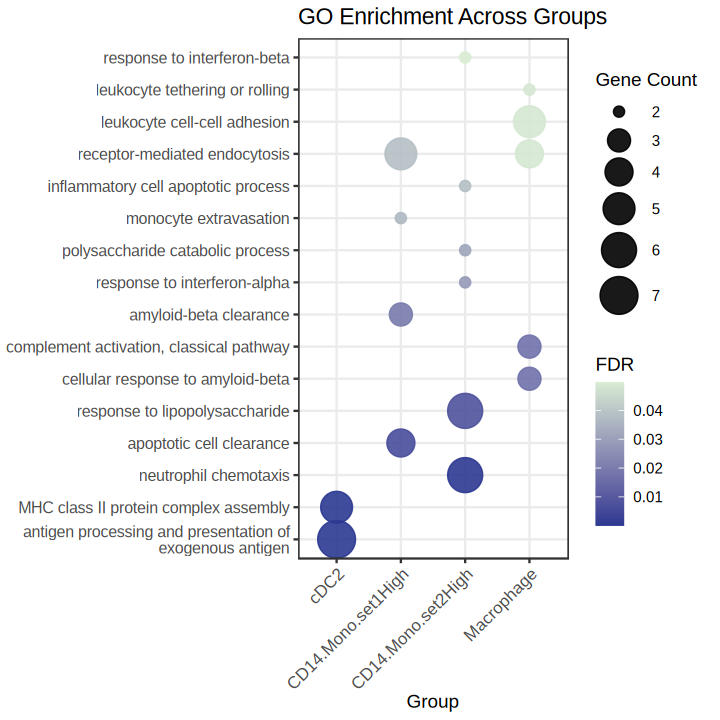

In [8]:
# ==== Usage Example ====
# Suppose your dataframe is called df with columns:
#   sample, Description, p.adjust, Count, GeneRatio
# You can run:
options(repr.plot.height = 6, repr.plot.width = 6)
p <- bubble_go_multi(df, top_n = 15, size_by = "GeneRatio")
print(p)
